## PRESENTATION-READY PLOTTING TEMPLATE
Drop this cell at the top of any Jupyter notebook to apply consistent,
colorblind-friendly styling to ALL matplotlib and seaborn plots.

Features:
  - Colorblind-friendly palette (Wong, 2011 — Nature Methods)
  - Font at presentation-readable sizes (min 18pt)
  - Legends always included and styled
  - Works with both matplotlib and seaborn

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# =============================================================================
# 1. COLORBLIND-FRIENDLY PALETTE  (Wong 2011, Nature Methods)
#    These 8 colors are maximally distinguishable for all color vision types.
# =============================================================================
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# =============================================================================
# 2. FONT DETECTION & SETTINGS
#    Auto-picks the best sans-serif font already on your machine.
#    Minimum size is 18pt; titles and labels are larger.
#
#    >>> To see ALL fonts available on your system, run in a cell:
#    >>>     from plot_template import list_fonts
#    >>>     list_fonts()
#
#    >>> To override the auto-picked font, set FONT_FAMILY before importing:
#    >>>     import plot_template
#    >>>     plot_template.FONT_FAMILY = "Verdana"
#    >>>     plot_template.apply_style()   # re-apply with your choice
# =============================================================================

def list_fonts(filter_text=None):
    """
    Print every font matplotlib can see on your system.
    Pass a string to filter, e.g. list_fonts("arial") or list_fonts("sans").
    """
    names = sorted({f.name for f in fm.fontManager.ttflist})
    if filter_text:
        names = [n for n in names if filter_text.lower() in n.lower()]
    print(f"Found {len(names)} font{'s' if len(names) != 1 else ''}:\n")
    for n in names:
        print(f"  • {n}")
    return names

# Preferred fonts in priority order (all clean presentation sans-serifs)
_FONT_PREFERENCES = [
    "Arial",
    "Helvetica",
    "Helvetica Neue",
    "Calibri",
    "Verdana",
    "Segoe UI",
    "Liberation Sans",
    "DejaVu Sans",
]

def _find_best_font():
    """Return the first preferred font that is actually installed."""
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    # Nothing from the preferred list — just grab any sans-serif we can find
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    # True last resort
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")
FONT_SIZE_TITLE   = 30      # figure / axes title
FONT_SIZE_LABEL   = 24      # axis labels
FONT_SIZE_TICK    = 20      # tick labels
FONT_SIZE_LEGEND  = 20      # legend text
FONT_SIZE_ANNOT   = 18      # annotations / text on plot

# =============================================================================
# 3. APPLY GLOBAL STYLE (matplotlib + seaborn)
#    Called automatically on import. Call again after changing FONT_FAMILY.
# =============================================================================

def apply_style():
    """Apply (or re-apply) the full presentation style using current settings."""
    mpl.rcParams.update({
        # --- Font -----------------------------------------------------------
        "font.family":        "sans-serif",
        "font.sans-serif":    [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size":          FONT_SIZE_ANNOT,       # base / fallback size

        # --- Axes -----------------------------------------------------------
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelsize":     FONT_SIZE_LABEL,
        "axes.labelweight":   "bold",
        "axes.prop_cycle":    mpl.cycler(color=CB_PALETTE),
        "axes.linewidth":     1.5,
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          True,
        "axes.axisbelow":     True,                   # grid behind data

        # --- Ticks ----------------------------------------------------------
        "xtick.labelsize":    FONT_SIZE_TICK,
        "ytick.labelsize":    FONT_SIZE_TICK,
        "xtick.major.width":  1.5,
        "ytick.major.width":  1.5,
        "xtick.major.size":   6,
        "ytick.major.size":   6,
        "xtick.direction":    "out",
        "ytick.direction":    "out",

        # --- Grid -----------------------------------------------------------
        "grid.color":         "#dbdbdb",
        "grid.linewidth":     0.8,
        "grid.alpha":         1.0,

        # --- Legend ----------------------------------------------------------
        "legend.fontsize":    FONT_SIZE_LEGEND,
        "legend.frameon":     True,
        "legend.framealpha":  0.9,
        "legend.edgecolor":   "#999999",
        "legend.fancybox":    True,
        "legend.shadow":      False,
        "legend.loc":         "best",

        # --- Lines & markers ------------------------------------------------
        "lines.linewidth":    2.5,
        "lines.markersize":   10,

        # --- Figure ---------------------------------------------------------
        "figure.figsize":     (12, 7),
        "figure.dpi":         100,
        "figure.facecolor":   "white",
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",

        # --- Saving ---------------------------------------------------------
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  "white",
    })

    sns.set_theme(
        style="whitegrid",
        font=FONT_FAMILY,
        font_scale=1.4,
        rc=mpl.rcParams,
    )
    sns.set_palette(CB_PALETTE)

    # Re-assert settings that seaborn's set_theme can override
    mpl.rcParams.update({
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelweight":   "bold",
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",
        "grid.color":         "#dbdbdb",
        "grid.alpha":         1.0,
    })

# Auto-apply on import
apply_style()

# =============================================================================
# 5. HELPER FUNCTIONS
# =============================================================================

def add_legend(ax=None, title=None, **kwargs):
    """
    Add a styled legend to the current or specified axes.
    Merges template defaults with any overrides you pass in.
    """
    ax = ax or plt.gca()
    defaults = dict(
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        framealpha=0.9,
        edgecolor="#999999",
        loc="best",
    )
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend


def get_colors(n=None):
    """
    Return the colorblind-friendly palette (or the first n colors).
    Useful when you need explicit color assignments.

    Usage:
        colors = get_colors(3)
        ax.bar(x, y1, color=colors[0], label="Group A")
        ax.bar(x, y2, color=colors[1], label="Group B")
    """
    if n is None:
        return CB_PALETTE.copy()
    return CB_PALETTE[:n]


def finalize(fig=None, tight=True):
    """
    Call at the end of every plot cell to tighten layout.
    """
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()


Font: Liberation Sans


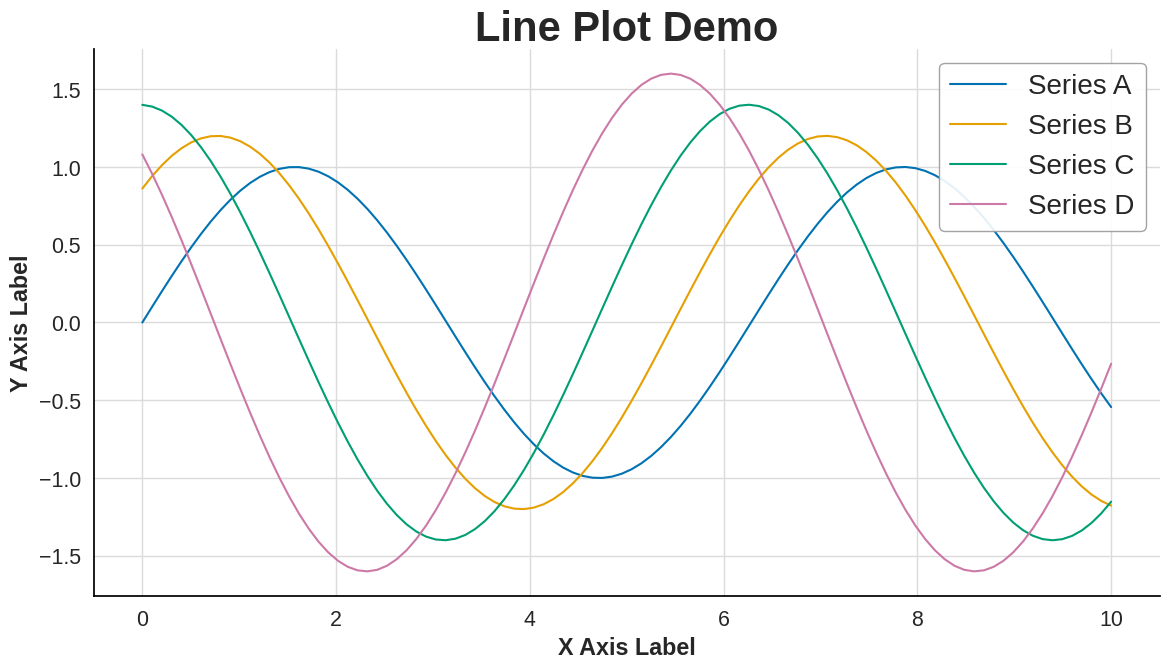

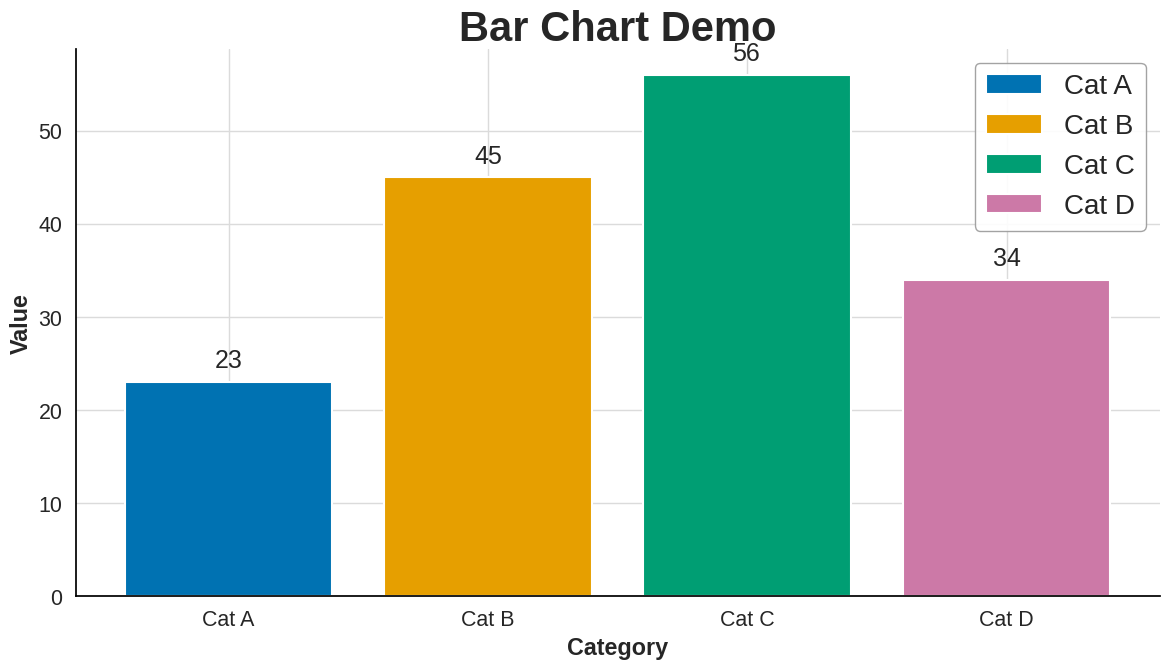

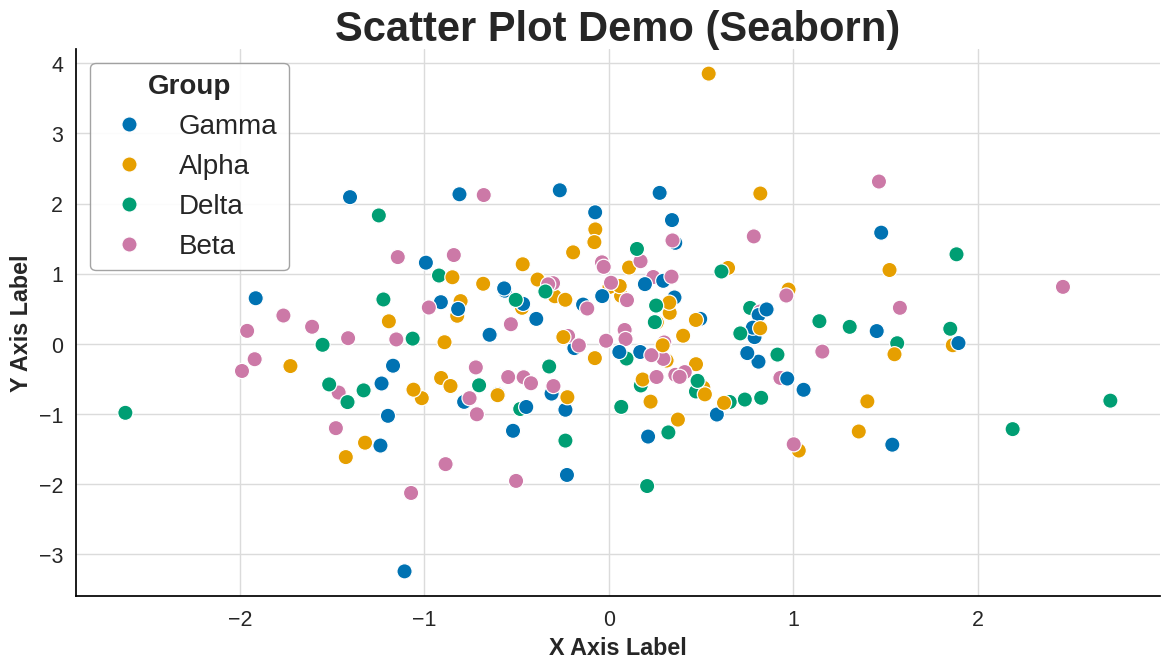

/tmp/ipykernel_7379/4076882987.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x="group", y="value", palette=CB_PALETTE[:4], ax=ax,


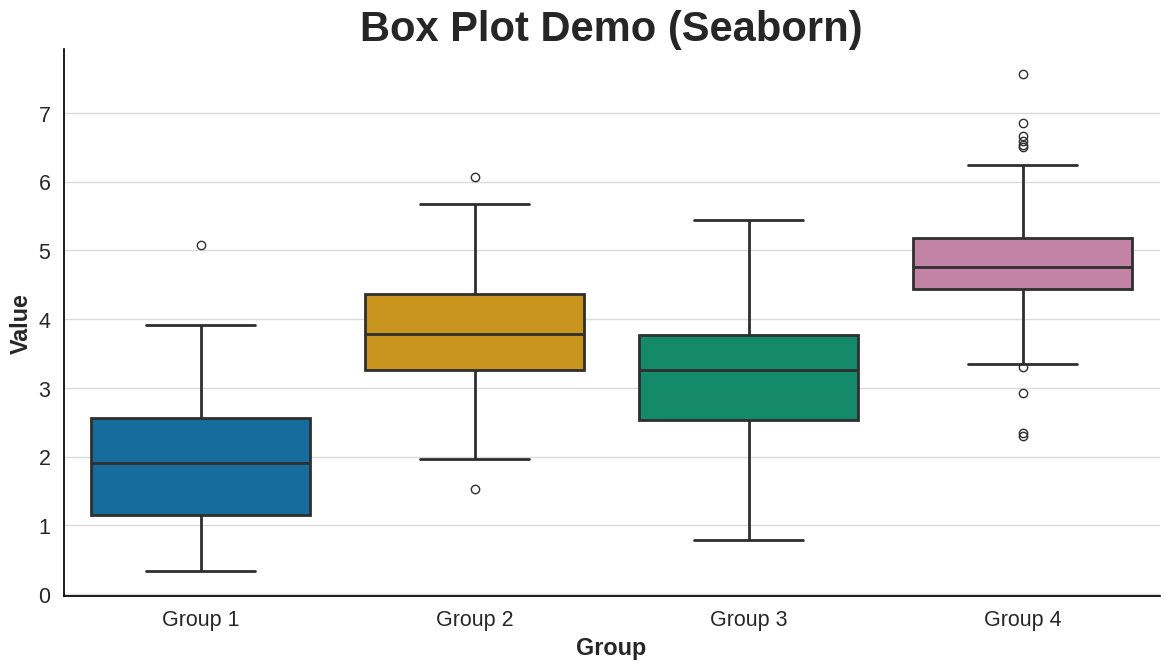

In [2]:
# =============================================================================
# 6. DEMO PLOTS  (delete this section when copying into your notebooks)
# =============================================================================
if __name__ == "__main__":

    np.random.seed(42)

    # --- Demo 1: Line plot (matplotlib) ----------------------------------
    fig, ax = plt.subplots()
    x = np.linspace(0, 10, 100)
    for i, label in enumerate(["Series A", "Series B", "Series C", "Series D"]):
        ax.plot(x, np.sin(x + i * 0.8) * (1 + 0.2 * i), label=label)
    ax.set_title("Line Plot Demo")
    ax.set_xlabel("X Axis Label")
    ax.set_ylabel("Y Axis Label")
    add_legend(ax)
    finalize()
    plt.show()

    # --- Demo 2: Bar chart (matplotlib) ----------------------------------
    fig, ax = plt.subplots()
    categories = ["Cat A", "Cat B", "Cat C", "Cat D"]
    colors = get_colors(4)
    values = [23, 45, 56, 34]
    bars = ax.bar(categories, values, color=colors, edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(val), ha="center", va="bottom",
                fontsize=FONT_SIZE_ANNOT, fontweight="normal")
    ax.set_title("Bar Chart Demo")
    ax.set_xlabel("Category")
    ax.set_ylabel("Value")
    ax.legend(bars, categories, fontsize=FONT_SIZE_LEGEND)
    finalize()
    plt.show()

    # --- Demo 3: Scatter plot (seaborn) ----------------------------------
    import pandas as pd
    df = pd.DataFrame({
        "x": np.random.randn(200),
        "y": np.random.randn(200),
        "group": np.random.choice(["Alpha", "Beta", "Gamma", "Delta"], 200),
    })
    fig, ax = plt.subplots()
    sns.scatterplot(data=df, x="x", y="y", hue="group", s=120,
                    palette=CB_PALETTE[:4], ax=ax)
    ax.set_title("Scatter Plot Demo (Seaborn)")
    ax.set_xlabel("X Axis Label")
    ax.set_ylabel("Y Axis Label")
    add_legend(ax, title="Group")
    finalize()
    plt.show()

    # --- Demo 4: Box plot (seaborn) --------------------------------------
    df2 = pd.DataFrame({
        "value": np.concatenate([np.random.normal(m, 1, 50) for m in [2, 4, 3, 5]]),
        "group": np.repeat(["Group 1", "Group 2", "Group 3", "Group 4"], 50),
    })
    fig, ax = plt.subplots()
    sns.boxplot(data=df2, x="group", y="value", palette=CB_PALETTE[:4], ax=ax,
                linewidth=2)
    ax.set_title("Box Plot Demo (Seaborn)")
    ax.set_xlabel("Group")
    ax.set_ylabel("Value")
    finalize()
    plt.show()